# Cloud Computing and Big Data Project: Benchmark Analysis
### Variant 5 — Manifest-based publishing (safe dataset versioning)

This notebook analyses the results of a cloud data lake benchmarking study comparing object storage performance across Amazon S3 and Azure Blob Storage. It evaluates upload, download, query and publishing workloads across multiple dataset sizes (S, M, L) and scan query patterns, using repeated measurements to ensure statistical stability.

## 1. Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import warnings
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings('ignore')

# ── Global Style: "Life of a Showgirl" ────────────────────────────────────
plt.rcParams.update({
    # figure
    'figure.dpi': 130,
    'figure.facecolor': 'white',

    # axes
    'axes.facecolor': 'white',
    'axes.edgecolor': '#E6B7C8',
    'axes.grid': True,

    # grid
    'grid.color': '#F7D6E0',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,

    # typography
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,

    # ticks
    'xtick.color': '#444444',
    'ytick.color': '#444444',
})

# compatibility for older matplotlib
colormaps = getattr(mpl, "colormaps", None)

# ── Showgirl palette ──────────────────────────────────────────────────────
PALETTE = {
    'spotlight': '#FFD166',   # warm stage gold
    'velvet':    '#8B1E3F',   # deep theatrical red
    'glitter':   '#F4A7B9',   # soft pink shimmer
    'midnight':  '#1B1B3A',   # backstage navy
    'applause':  '#EC4D25',   # loud emotional orange-red
    'haze':      '#71B6AF',   # dreamy blue-green haze
}

# backend colors
COLORS = {
    's3': PALETTE['applause'],
    'azure': PALETTE['haze'],
}

SIZE_ORDER = ['S', 'M', 'L']

SIZE_LABELS = {
    'S': 'S\n(~1 GB)',
    'M': 'M\n(~5 GB)',
    'L': 'L\n(~10 GB)'
}

SIZE_COLORS = {
    'S': PALETTE['glitter'],
    'M': PALETTE['spotlight'],
    'L': PALETTE['midnight']
}

PRESET_DESC = {
    'v1': 'region+date\n(H1 1812)',
    'v2': 'event+date\n(H2 1812)',
    'v3': 'character\n+region',
    'v4': 'mood+event\n(high sel.)',
    'v5': 'date only\n(6 months)',
    'v6': 'region\nonly',
    'v7': 'event\nonly',
}

In [29]:
df = pd.read_csv("results/results.csv")


In [4]:
def grouped_bars(ax, df, test_type, metric, title, ylabel):
    sub = df[df['test_type'] == test_type]

    backends = sorted(sub['backend'].unique())
    sizes = [s for s in SIZE_ORDER if s in sub['size_label'].values]

    x = np.arange(len(sizes))
    n = len(backends)

    width = 0.35
    offsets = np.linspace(-(n - 1) * width / 2, (n - 1) * width / 2, n)

    for i, backend in enumerate(backends):
        bsub = sub[sub['backend'] == backend].groupby('size_label')[metric].agg(['mean', 'std'])

        means = [bsub.loc[s, 'mean'] if s in bsub.index else np.nan for s in sizes]
        stds  = [bsub.loc[s, 'std'] if s in bsub.index else 0 for s in sizes]

        color = COLORS.get(backend, PALETTE['glitter'])

        bars = ax.bar(
            x + offsets[i],
            means,
            width * 0.9,
            label=str(backend).upper(),
            color=color,
            yerr=stds,
            capsize=4,
            error_kw={'lw': 1.2}
        )

        for bar, m in zip(bars, means):
            if not np.isnan(m):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.02,
                    f'{m:.1f}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([SIZE_LABELS[s] for s in sizes])
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

## 2. Upload/Download time

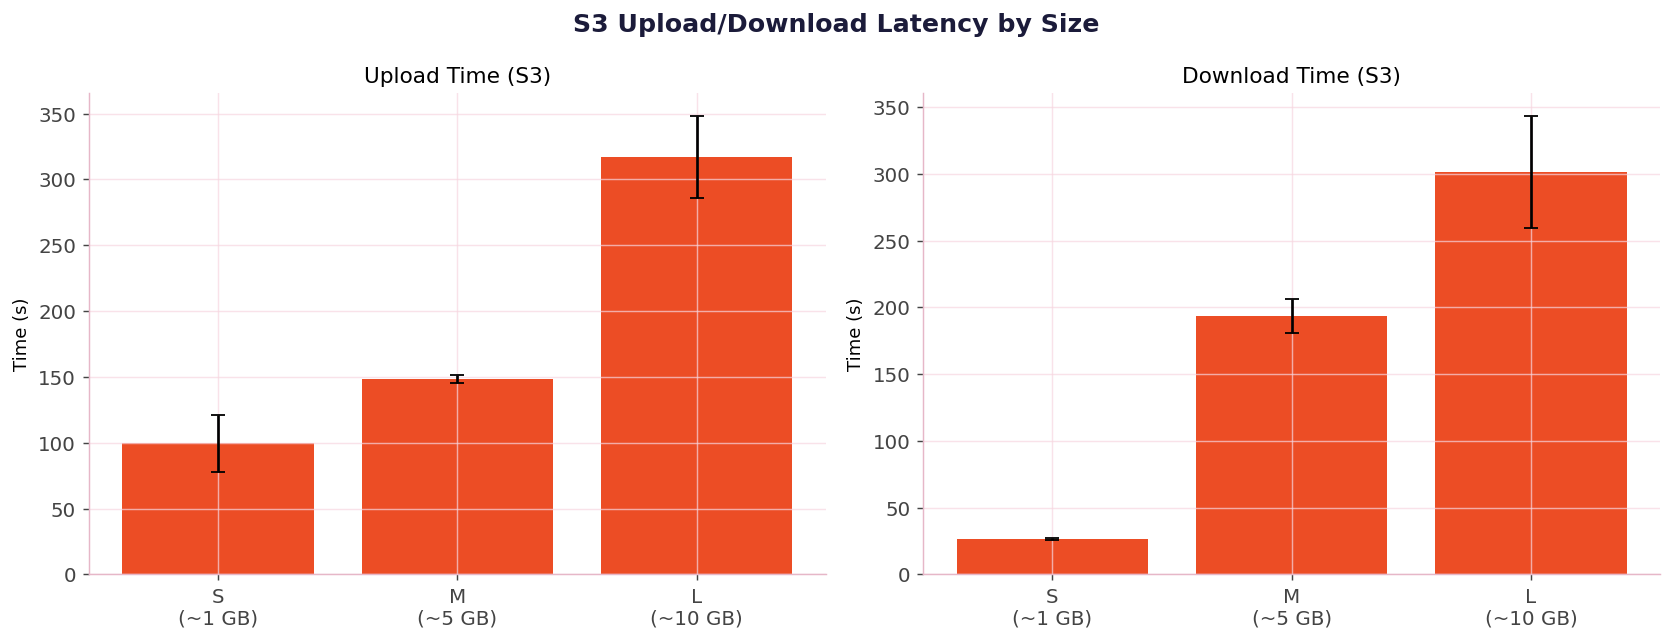

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Upload ─────────────────────────────────────────────
upload = df[(df['test_type'] == 'upload') & (df['backend'] == 's3')]

u = (
  upload.groupby('size_label')['elapsed_ms'].agg(['mean', 'std']).reindex(SIZE_ORDER)
  / 1000 # convert from ms to s
)

x = np.arange(len(u))

axes[0].bar(
    x,
    u['mean'],
    yerr=u['std'],
    capsize=4,
    color=COLORS['s3']
)

axes[0].set_xticks(x)
axes[0].set_xticklabels([SIZE_LABELS[s] for s in u.index])
axes[0].set_title('Upload Time (S3)')
axes[0].set_ylabel('Time (s)')
axes[0].set_facecolor("white")
axes[0].grid(True, color="#F7D6E0", linewidth=0.8)

# ── Download ───────────────────────────────────────────
download = df[(df['test_type'] == 'download') & (df['backend'] == 's3')]

d = (
  download.groupby('size_label')['elapsed_ms'].agg(['mean', 'std']).reindex(SIZE_ORDER)
  / 1000
)

x = np.arange(len(d))

axes[1].bar(
    x,
    d['mean'],
    yerr=d['std'],
    capsize=4,
    color=COLORS['s3']
)

axes[1].set_xticks(x)
axes[1].set_xticklabels([SIZE_LABELS[s] for s in d.index])
axes[1].set_title('Download Time (S3)')
axes[1].set_ylabel('Time (s)')
axes[1].set_facecolor("white")
axes[1].grid(True, color="#F7D6E0", linewidth=0.8)

# ── Global title ───────────────────────────────────────
fig.suptitle(
    'S3 Upload/Download Latency by Size',
    fontsize=14,
    fontweight='bold',
    color=PALETTE['midnight']
)

plt.tight_layout()
plt.show()

## 3. Warmup Effect

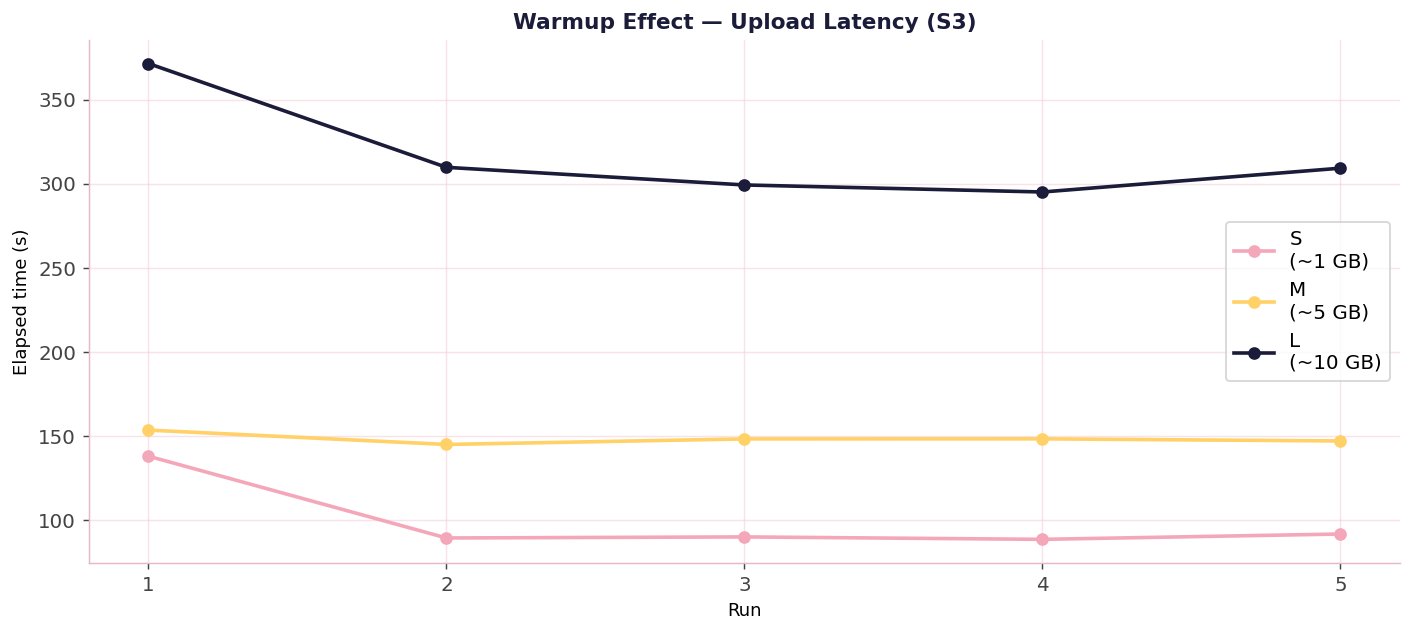

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

sub = df[(df['test_type'] == 'upload') & (df['backend'] == 's3')]

for size in SIZE_ORDER:
    ssub = sub[sub['size_label'] == size].reset_index(drop=True)

    if len(ssub) == 0:
        continue

    ssub['elapsed_s'] = ssub['elapsed_ms'] / 1000

    runs = np.arange(1, len(ssub) + 1)

    ax.plot(
        runs,
        ssub['elapsed_s'],
        marker='o',
        linewidth=2,
        label=SIZE_LABELS[size],
        color=SIZE_COLORS[size]
    )

ax.set_title('Warmup Effect — Upload Latency (S3)', fontweight='bold', color=PALETTE['midnight'])
ax.set_xlabel('Run')
ax.set_ylabel('Elapsed time (s)')

ax.set_facecolor("white")
ax.grid(True, color="#F7D6E0", linewidth=0.8)

ax.legend()

# Use integers for run numbers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Listing Overhead

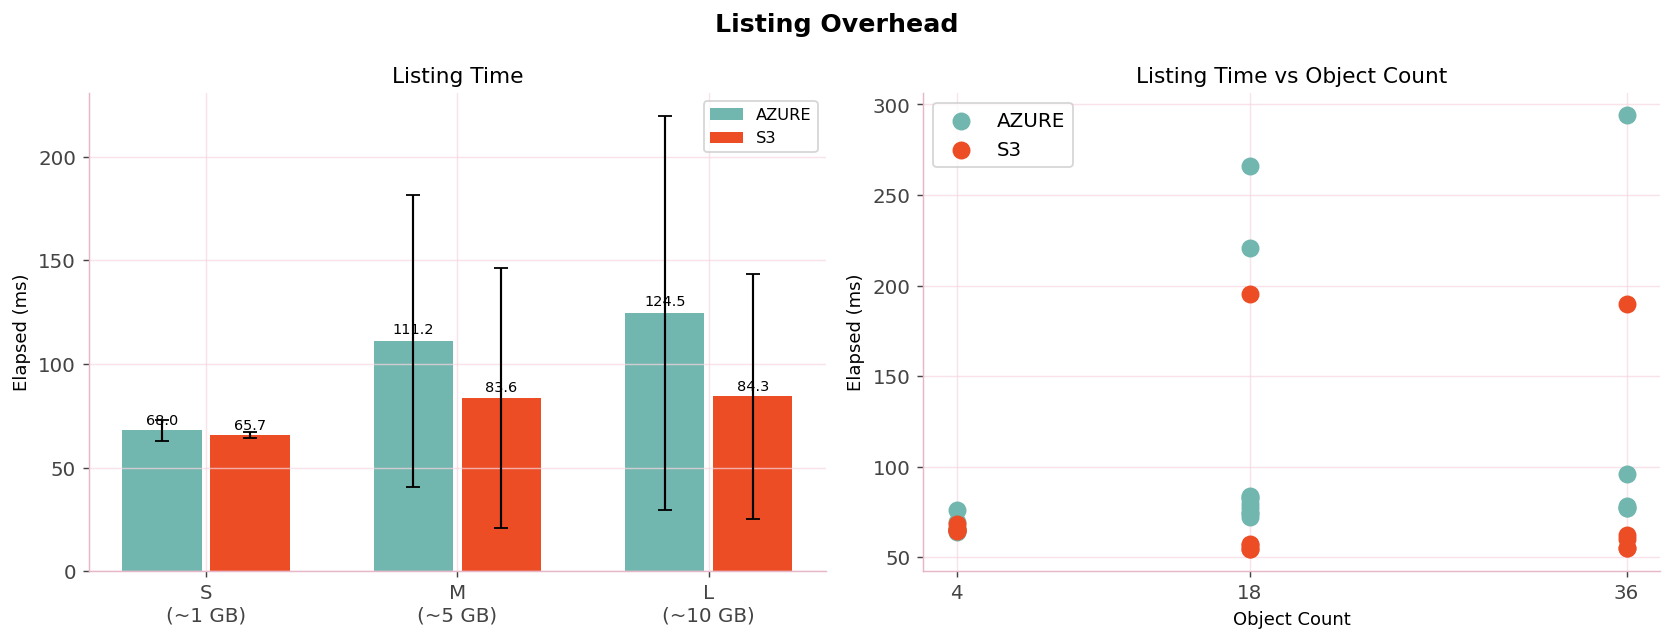

mean_elapsed_ms  std_elapsed_ms  object_count  \
backend size_label                                                  
azure   L                    124.50           95.23            36   
        M                    111.21           70.47            18   
        S                     67.95            5.04             4   
s3      L                     84.32           59.04            36   
        M                     83.56           62.55            18   
        S                     65.65            1.58             4   

                    list_requests  
backend size_label                 
azure   L                     1.0  
        M                     1.0  
        S                     1.0  
s3      L                     1.0  
        M                     1.0  
        S                     1.0

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bars(axes[0], df, 'listing', 'elapsed_ms', 'Listing Time', 'Elapsed (ms)')

listing_df = df[df['test_type'] == 'listing'].dropna(subset=['object_count', 'elapsed_ms'])
for backend, grp in listing_df.groupby('backend'):
    axes[1].scatter(grp['object_count'], grp['elapsed_ms'],
                    label=backend.upper(), color=COLORS[backend], s=80, zorder=3)

axes[1].set_xlabel('Object Count')
axes[1].set_ylabel('Elapsed (ms)')
axes[1].set_title('Listing Time vs Object Count')
axes[1].legend()
axes[1].set_xticks(sorted(listing_df['object_count'].unique()))

fig.suptitle('Listing Overhead', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df[df['test_type'] == 'listing'].groupby(['backend', 'size_label']).agg(
    mean_elapsed_ms=('elapsed_ms', 'mean'),
    std_elapsed_ms=('elapsed_ms', 'std'),
    object_count=('object_count', 'first'),
    list_requests=('list_requests', 'first'),
).round(2)

## 5. Parquet Scan — Query Performance & Predicate Pushdown

We ran 7 query presets with different filter combinations to study how Parquet's predicate pushdown affects scan time.

| Preset | Filters |
|--------|--------|
| v1 | region=Pemberley + date H1 1812 |
| v2 | event=ball_attendance + date H2 1812 |
| v3 | character=Mr. Darcy + region=Pemberley |
| v4 | mood=mortified + event=proposal_rejected (high selectivity) |
| v5 | date range only (6 months) |
| v6 | region=Longbourn only |
| v7 | event=dramatic_hand_flex only |

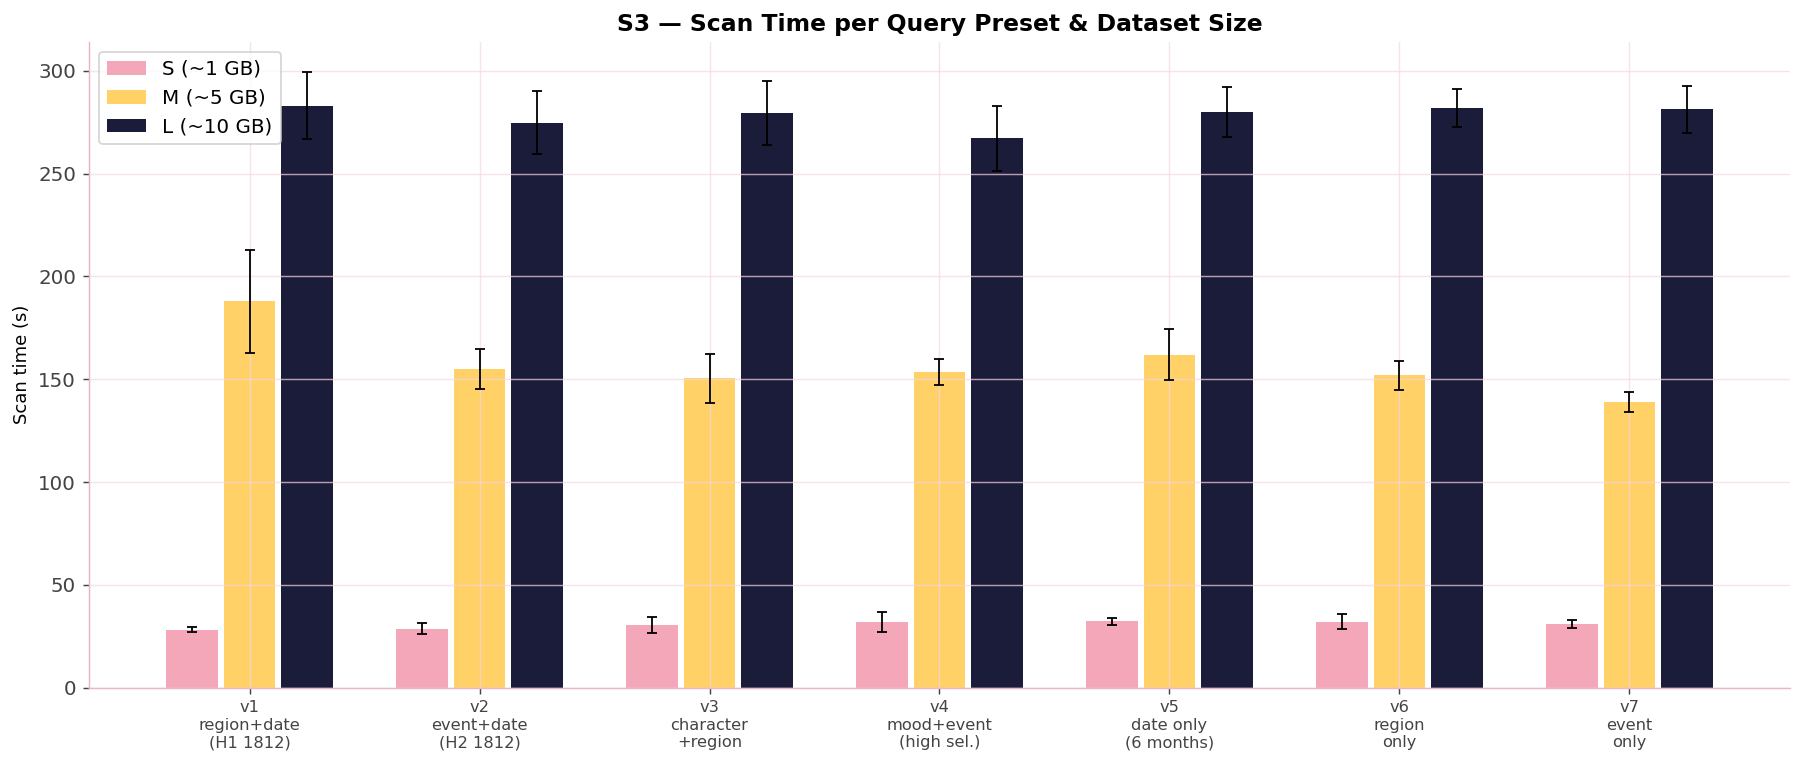

In [ ]:
scan_df = df[df['test_type'].str.startswith('scan/')].copy()
scan_df['preset'] = scan_df['test_type'].str.replace('scan/', '')
s3_scan = scan_df[scan_df['backend'] == 's3']
presets = sorted(s3_scan['preset'].unique())
sizes_present = [s for s in SIZE_ORDER if s in s3_scan['size_label'].values]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(presets))
width = 0.25
offsets = np.linspace(-(len(sizes_present)-1)*width/2, (len(sizes_present)-1)*width/2, len(sizes_present))

for i, size in enumerate(sizes_present):
    sub = s3_scan[s3_scan['size_label']==size].groupby('preset')['scan_ms'].agg(['mean','std']) / 1000
    means = [sub.loc[p,'mean'] if p in sub.index else np.nan for p in presets]
    stds  = [sub.loc[p,'std']  if p in sub.index else 0      for p in presets]
    ax.bar(x+offsets[i], means, width*0.9, label=SIZE_LABELS[size].replace('\n',' '),
           color=SIZE_COLORS[size], yerr=stds, capsize=3, error_kw={'lw':1})

ax.set_title('S3 — Scan Time per Query Preset & Dataset Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Scan time (s)')
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n{PRESET_DESC.get(p,'')}" for p in presets], fontsize=9)
ax.legend(); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

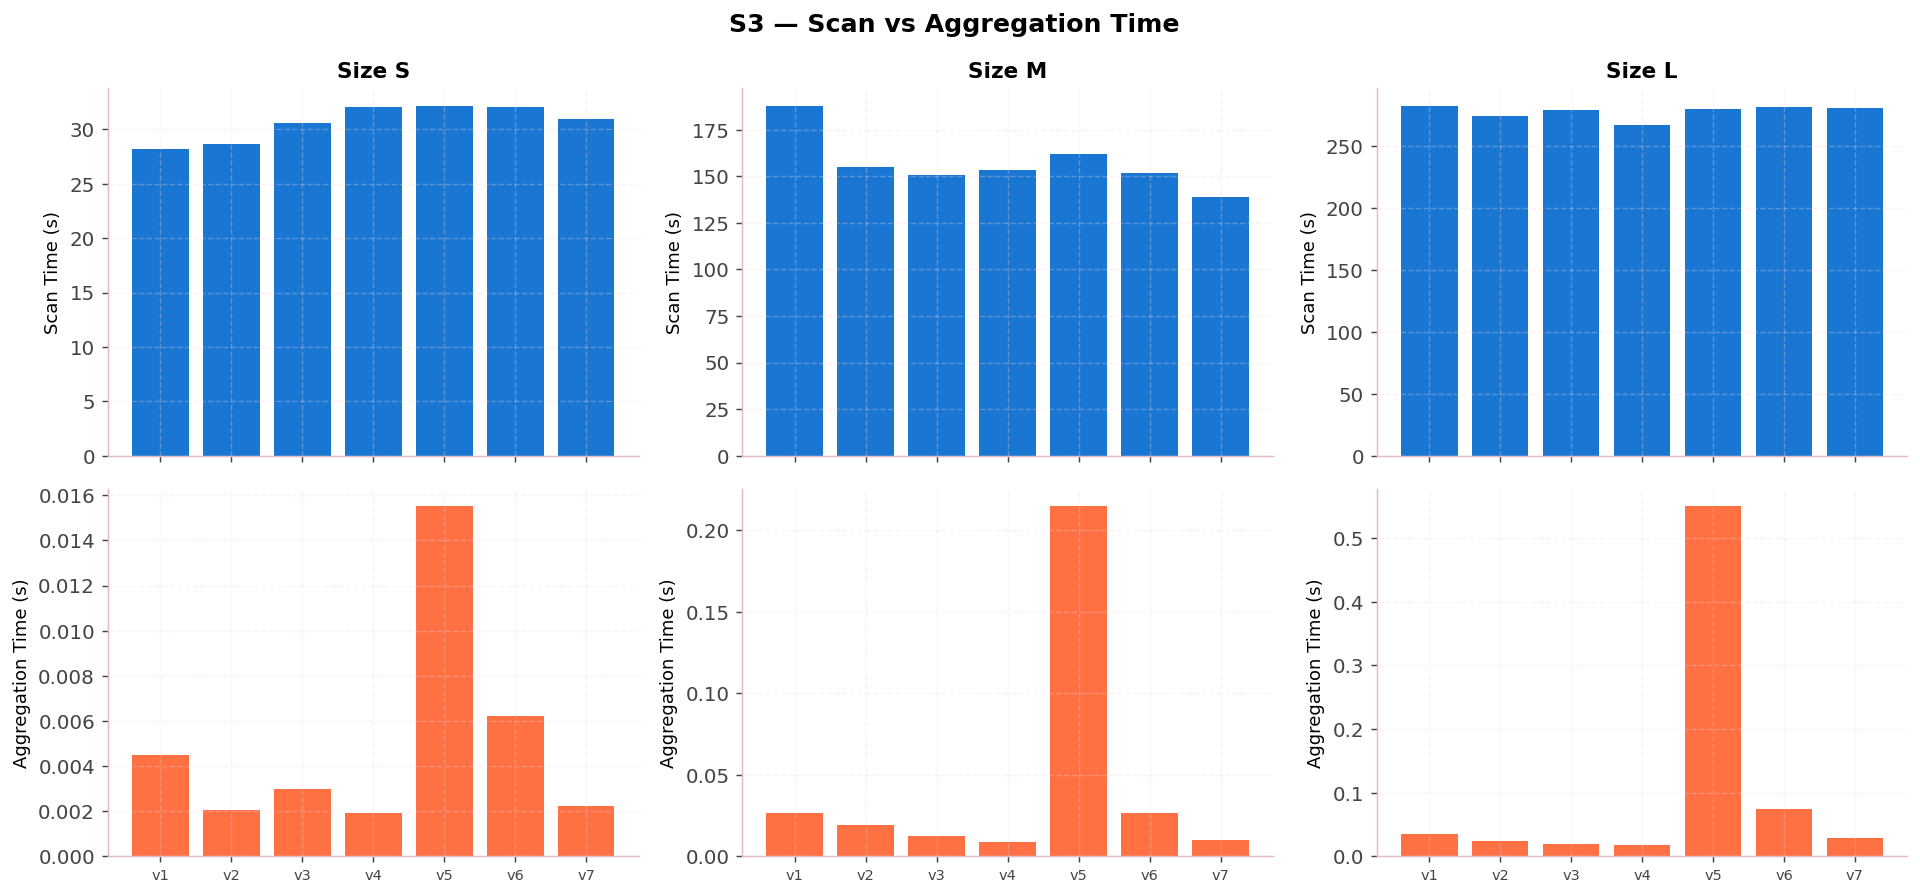

In [ ]:
# Scan vs Aggregation time split
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 7),
    sharex='col'
)

for col, size in enumerate(['S', 'M', 'L']):

    if size not in sizes_present:
        axes[0, col].set_visible(False)
        axes[1, col].set_visible(False)
        continue

    sub = (
        s3_scan[s3_scan['size_label'] == size]
        .groupby('preset')[['scan_ms', 'agg_ms']]
        .mean()
        / 1000
    )

    sub = sub.reindex(presets).dropna()

    x = np.arange(len(sub))

    # ── Top: Scan Time ───────────────────────
    axes[0, col].bar(
        x,
        sub['scan_ms'],
        color='#1976D2'
    )

    axes[0, col].set_title(
        f'Size {size}',
        fontweight='bold'
    )

    axes[0, col].set_ylabel('Scan Time (s)')

    axes[0, col].grid(
        True,
        linestyle='--',
        alpha=0.3
    )

    # ── Bottom: Aggregation Time ─────────────
    axes[1, col].bar(
        x,
        sub['agg_ms'],
        color='#FF7043'
    )

    axes[1, col].set_ylabel('Aggregation Time (s)')

    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(
        sub.index,
        fontsize=8
    )

    axes[1, col].grid(
        True,
        linestyle='--',
        alpha=0.3
    )

# ── Global title ────────────────────────────
fig.suptitle(
    'S3 — Scan vs Aggregation Time',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [57]:
df[['scan_ms', 'agg_ms']].describe()

,scan_ms,agg_ms
count,218.000000,218.000000
mean,247570.020103,73.071055
std,212114.589078,132.667223
min,106.380917,0.273417
25%,32025.540750,8.537072
50%,211122.431625,23.852500
75%,365778.592844,60.778584
max,903001.602500,669.292625


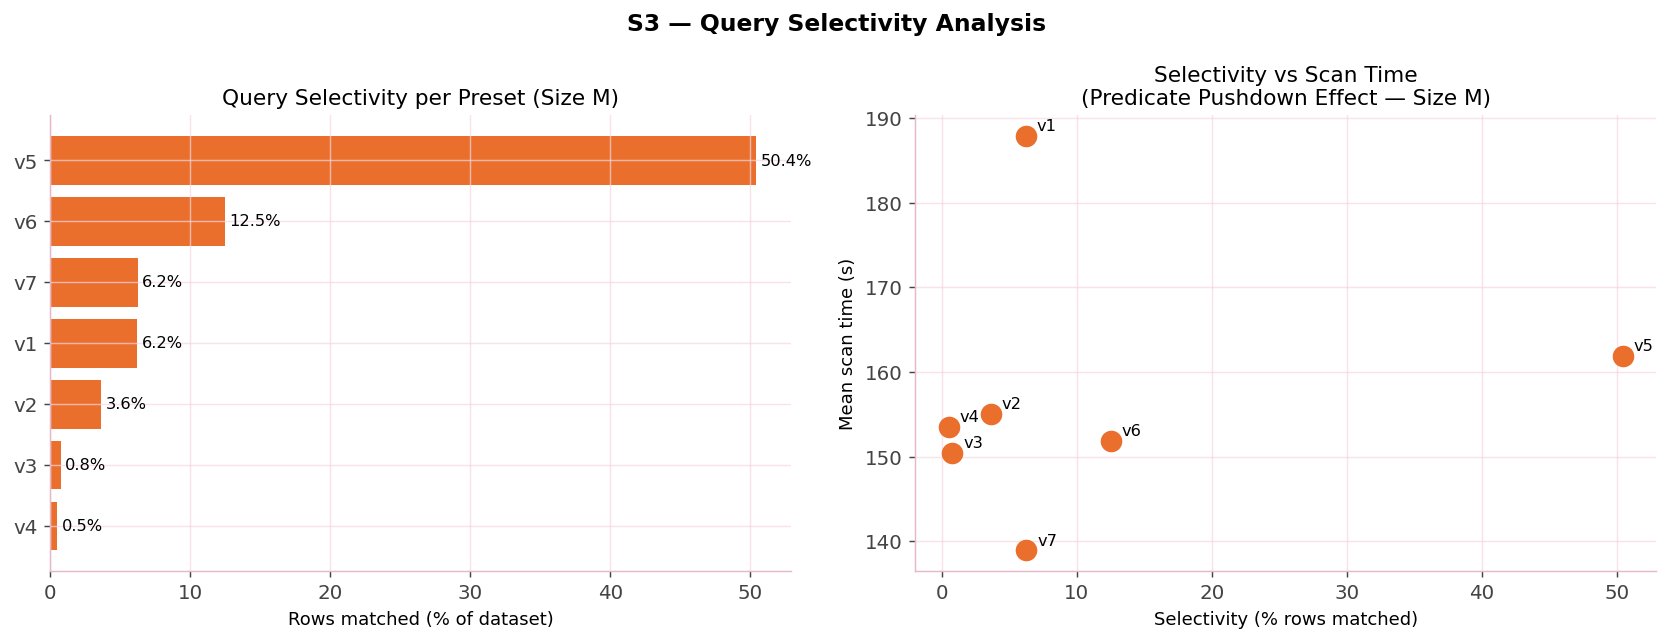

preset  selectivity_pct  mean_scan_s  rows_matched  rows_scanned
    v1             6.23   187.868306     1114572.0    17900000.0
    v2             3.64   155.068007      652316.0    17900000.0
    v3             0.78   150.450877      139798.0    17900000.0
    v4             0.52   153.516775       92902.0    17900000.0
    v5            50.41   161.935743     9023560.0    17900000.0
    v6            12.49   151.882195     2236458.0    17900000.0
    v7             6.25   138.918132     1119523.0    17900000.0


In [ ]:
# Query selectivity — rows matched vs rows scanned
sel = s3_scan[s3_scan['size_label']=='M'].groupby('preset').agg(
    rows_scanned=('rows_scanned','first'),
    rows_matched=('rows_matched','mean'),
    mean_scan_ms=('scan_ms','mean'),
).reset_index()
sel['selectivity_pct'] = (sel['rows_matched'] / sel['rows_scanned'] * 100).round(2)
sel['mean_scan_s'] = sel['mean_scan_ms'] / 1000
sel_sorted = sel.sort_values('selectivity_pct')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].barh(sel_sorted['preset'], sel_sorted['selectivity_pct'], color='#EA6F2D')
axes[0].set_xlabel('Rows matched (% of dataset)')
axes[0].set_title('Query Selectivity per Preset (Size M)')
for bar, (_, row) in zip(bars, sel_sorted.iterrows()):
    axes[0].text(row['selectivity_pct']+0.3, bar.get_y()+bar.get_height()/2,
                 f"{row['selectivity_pct']:.1f}%", va='center', fontsize=9)

axes[1].scatter(sel['selectivity_pct'], sel['mean_scan_s'], s=120, color="#EA6F2D", zorder=3)
for _, row in sel.iterrows():
    axes[1].annotate(row['preset'], (row['selectivity_pct'], row['mean_scan_s']),
                     textcoords='offset points', xytext=(6,3), fontsize=9)
axes[1].set_xlabel('Selectivity (% rows matched)')
axes[1].set_ylabel('Mean scan time (s)')
axes[1].set_title('Selectivity vs Scan Time\n(Predicate Pushdown Effect — Size M)')
fig.suptitle('S3 — Query Selectivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(sel[['preset','selectivity_pct','mean_scan_s','rows_matched','rows_scanned']].to_string(index=False))

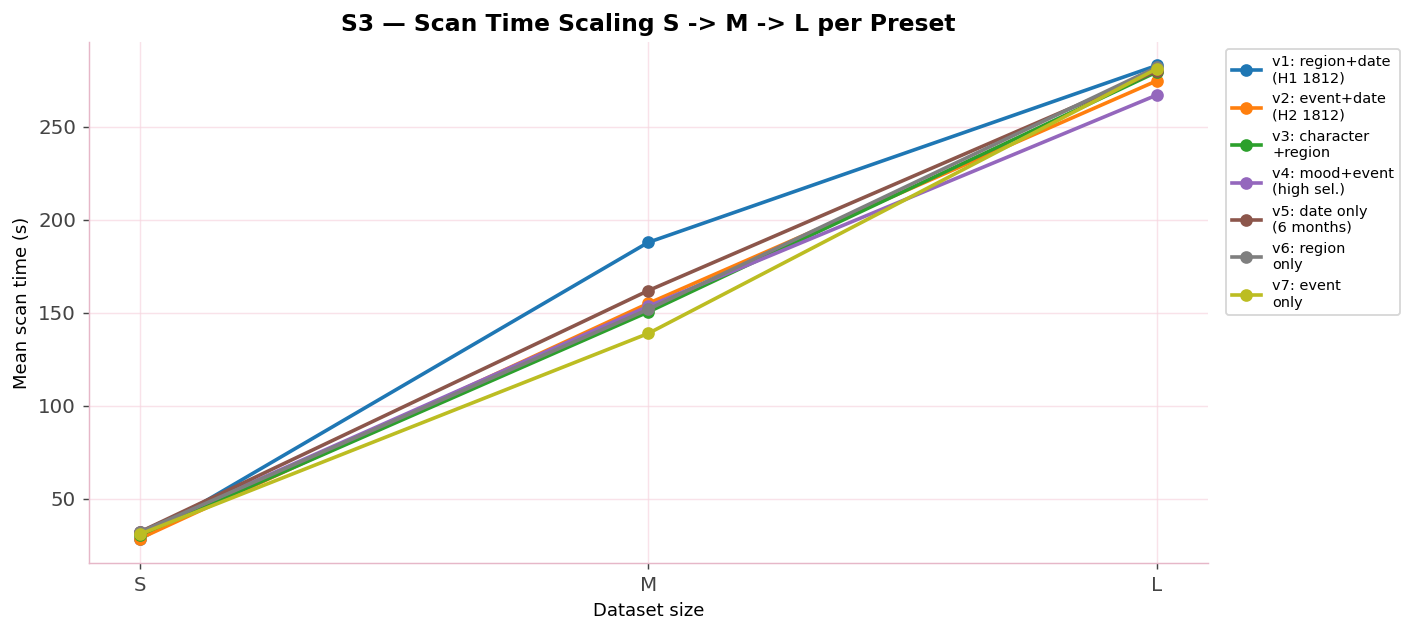

In [ ]:
# Scan time scaling S -> M -> L
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap('tab10')

for i, preset in enumerate(presets):
    sub = (
        s3_scan[s3_scan['preset'] == preset]
        .groupby('size_label')['scan_ms']
        .mean()
        / 1000
    )

    sub = sub.reindex(SIZE_ORDER).dropna()

    if len(sub) > 0:
        ax.plot(
            sub.index.astype(str),
            sub.values,
            marker='o',
            label=f"{preset}: {PRESET_DESC.get(preset, '')}",
            color=cmap(i / len(presets)),
            linewidth=2
        )

ax.set_title(
    'S3 — Scan Time Scaling S -> M -> L per Preset',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel('Mean scan time (s)')
ax.set_xlabel('Dataset size')

ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

## 6. Publish Benchmark — Manifest-Based Publishing Overhead

The publish workflow: **validation** (read dataset, check schema + stats) then **manifest write** (`latest.json` to S3).

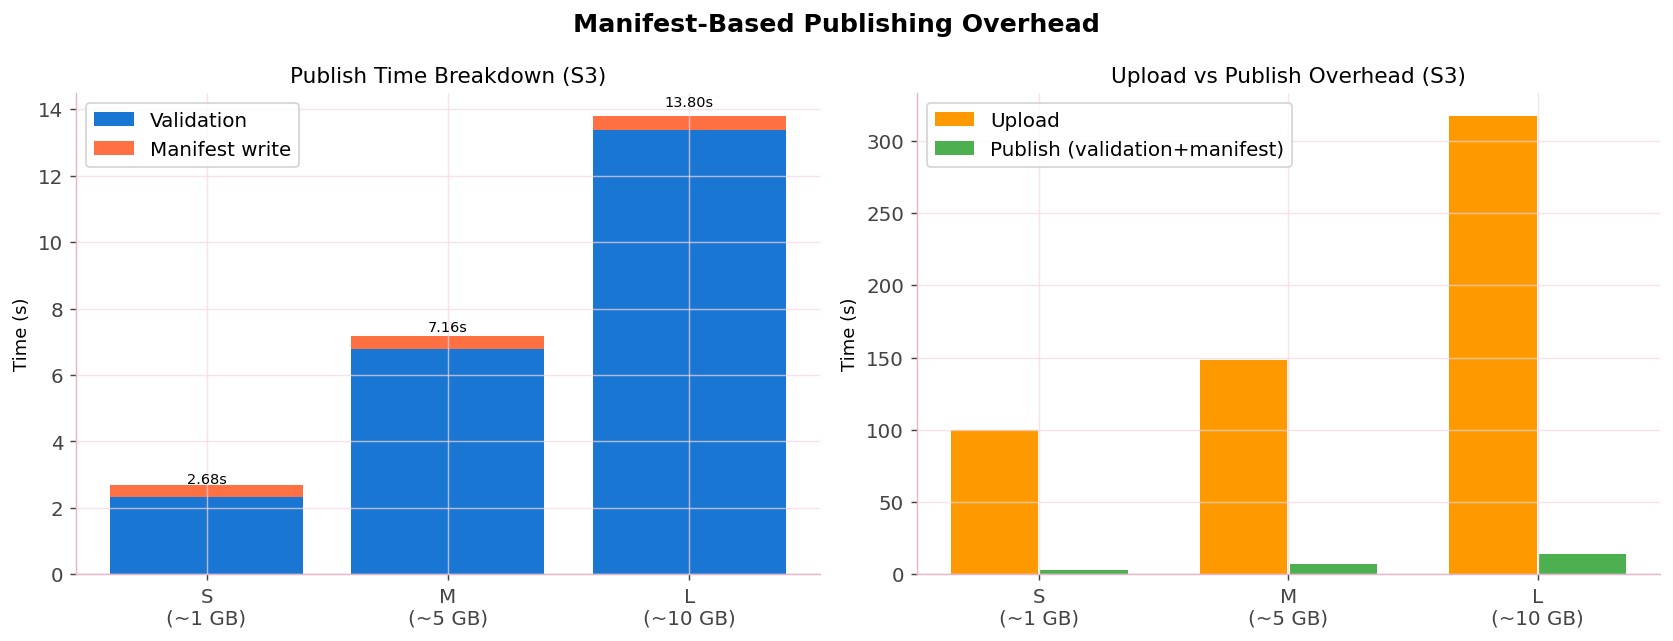

           validation_ms         metadata_ms       elapsed_ms        
                    mean     std        mean   std       mean     std
size_label                                                           
L                13384.2  1501.0       411.6  24.1    13795.7  1494.9
M                 6785.0   396.9       379.4  20.1     7164.4   404.8
S                 2337.3   265.2       341.4  84.6     2678.7   344.1


In [ ]:
pub_df = df[(df['test_type']=='publish') & (df['backend']=='s3')]

if pub_df.empty:
    print("No publish data available yet.")
else:
    pub_agg    = pub_df.groupby('size_label')[['validation_ms','metadata_ms','elapsed_ms']].mean() / 1000
    pub_agg    = pub_agg.reindex([s for s in SIZE_ORDER if s in pub_agg.index])
    upload_agg = df[(df['test_type']=='upload') & (df['backend']=='s3')].groupby('size_label')['elapsed_ms'].mean() / 1000

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x = np.arange(len(pub_agg))
    axes[0].bar(x, pub_agg['validation_ms'], label='Validation', color='#1976D2')
    axes[0].bar(x, pub_agg['metadata_ms'], bottom=pub_agg['validation_ms'],
                label='Manifest write', color='#FF7043')
    axes[0].set_title('Publish Time Breakdown (S3)')
    axes[0].set_ylabel('Time (s)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([SIZE_LABELS[s] for s in pub_agg.index])
    axes[0].legend()
    for i, (s, row) in enumerate(pub_agg.iterrows()):
        axes[0].text(i, row['elapsed_ms']*1.02, f"{row['elapsed_ms']:.2f}s",
                     ha='center', fontsize=8)

    sizes_both = [s for s in SIZE_ORDER if s in pub_agg.index and s in upload_agg.index]
    x2 = np.arange(len(sizes_both))
    axes[1].bar(x2-0.18, [upload_agg[s] for s in sizes_both], 0.35,
                label='Upload', color='#FF9900')
    axes[1].bar(x2+0.18, [pub_agg.loc[s,'elapsed_ms'] for s in sizes_both], 0.35,
                label='Publish (validation+manifest)', color='#4CAF50')
    axes[1].set_title('Upload vs Publish Overhead (S3)')
    axes[1].set_ylabel('Time (s)')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels([SIZE_LABELS[s] for s in sizes_both])
    axes[1].legend()

    fig.suptitle('Manifest-Based Publishing Overhead', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(pub_df.groupby('size_label')[['validation_ms','metadata_ms','elapsed_ms']]
          .agg(['mean','std']).round(1).to_string())

## 7. Azure vs S3 Comparison (Bonus)

> Azure data is partial (S and M, some presets). Plots show only available combinations and update automatically when more data is added.

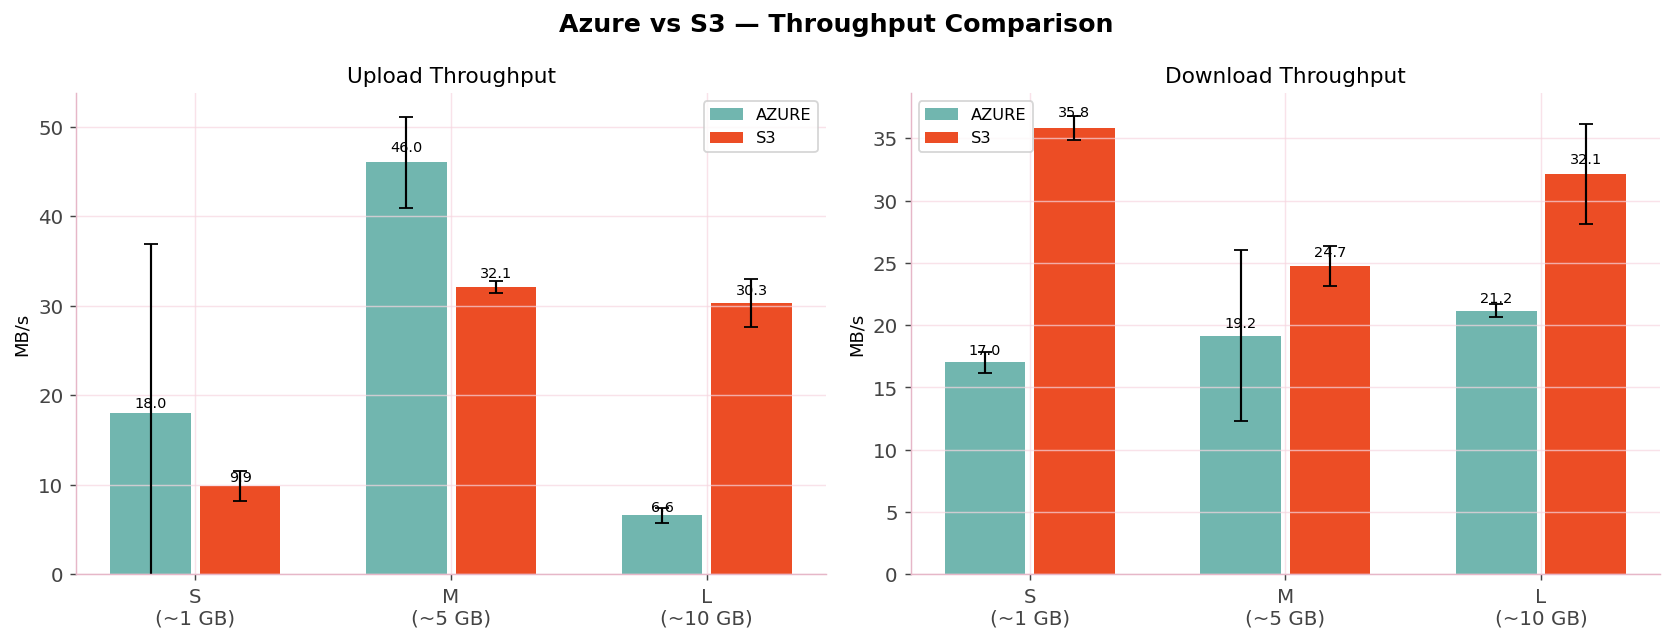

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bars(axes[0], df, 'upload',   'throughput_mb_s', 'Upload Throughput',   'MB/s')
grouped_bars(axes[1], df, 'download', 'throughput_mb_s', 'Download Throughput', 'MB/s')
fig.suptitle('Azure vs S3 — Throughput Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

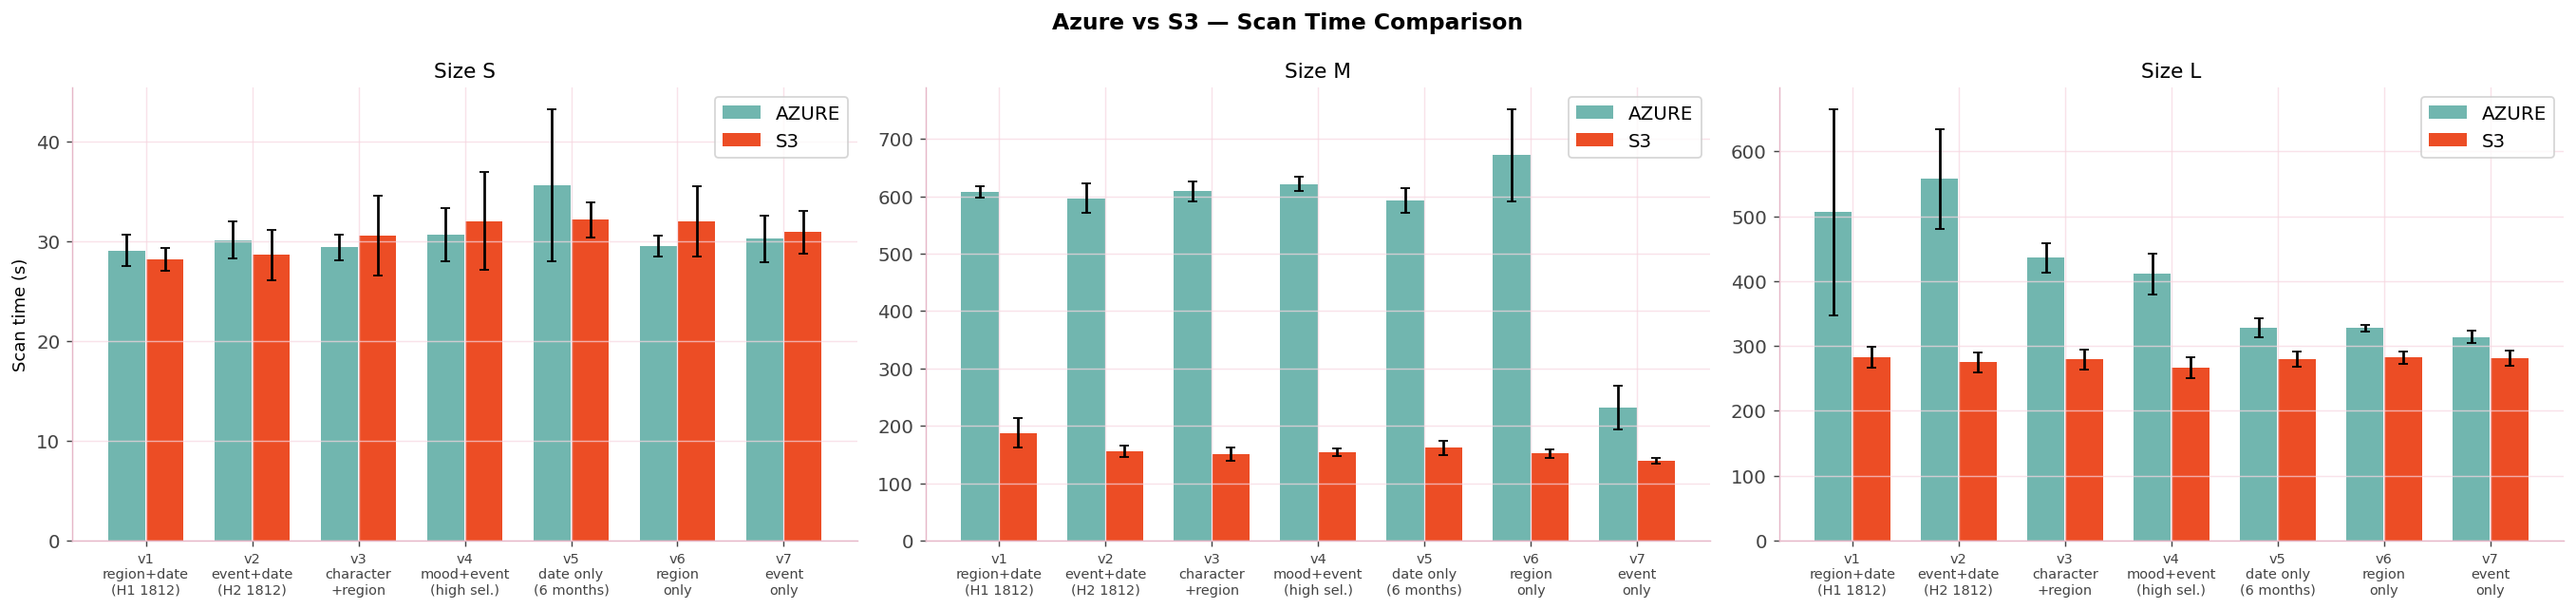

In [ ]:
common_presets = sorted(
    set(scan_df[scan_df['backend'] == 's3']['preset']) &
    set(scan_df[scan_df['backend'] == 'azure']['preset'])
)
common_sizes = [s for s in SIZE_ORDER if
    s in scan_df[scan_df['backend'] == 's3']['size_label'].values and
    s in scan_df[scan_df['backend'] == 'azure']['size_label'].values
]

if not common_presets or not common_sizes:
    print("No overlapping scan data between backends yet.")
else:
    both = scan_df[
        scan_df['preset'].isin(common_presets) &
        scan_df['size_label'].isin(common_sizes)
    ]
    fig, axes = plt.subplots(1, len(common_sizes), figsize=(7 * len(common_sizes), 5))
    axes = np.atleast_1d(axes)

    for ax, size in zip(axes, common_sizes):
        sub = both[both['size_label'] == size]
        x = np.arange(len(common_presets))
        for i, backend in enumerate(sorted(sub['backend'].unique())):
            bsub = sub[sub['backend'] == backend].groupby('preset')['scan_ms'].agg(['mean', 'std']) / 1000
            means = [bsub.loc[p, 'mean'] if p in bsub.index else np.nan for p in common_presets]
            stds  = [bsub.loc[p, 'std']  if p in bsub.index else 0      for p in common_presets]
            offset = -0.18 if i == 0 else 0.18
            ax.bar(x + offset, means, 0.35, label=backend.upper(),
                   color=COLORS[backend], yerr=stds, capsize=3)
        ax.set_title(f'Size {size}')
        ax.set_ylabel('Scan time (s)' if size == common_sizes[0] else '')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{p}\n{PRESET_DESC.get(p, '')}" for p in common_presets], fontsize=8)
        ax.legend()

    fig.suptitle('Azure vs S3 — Scan Time Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Azure chunking vs no chunking

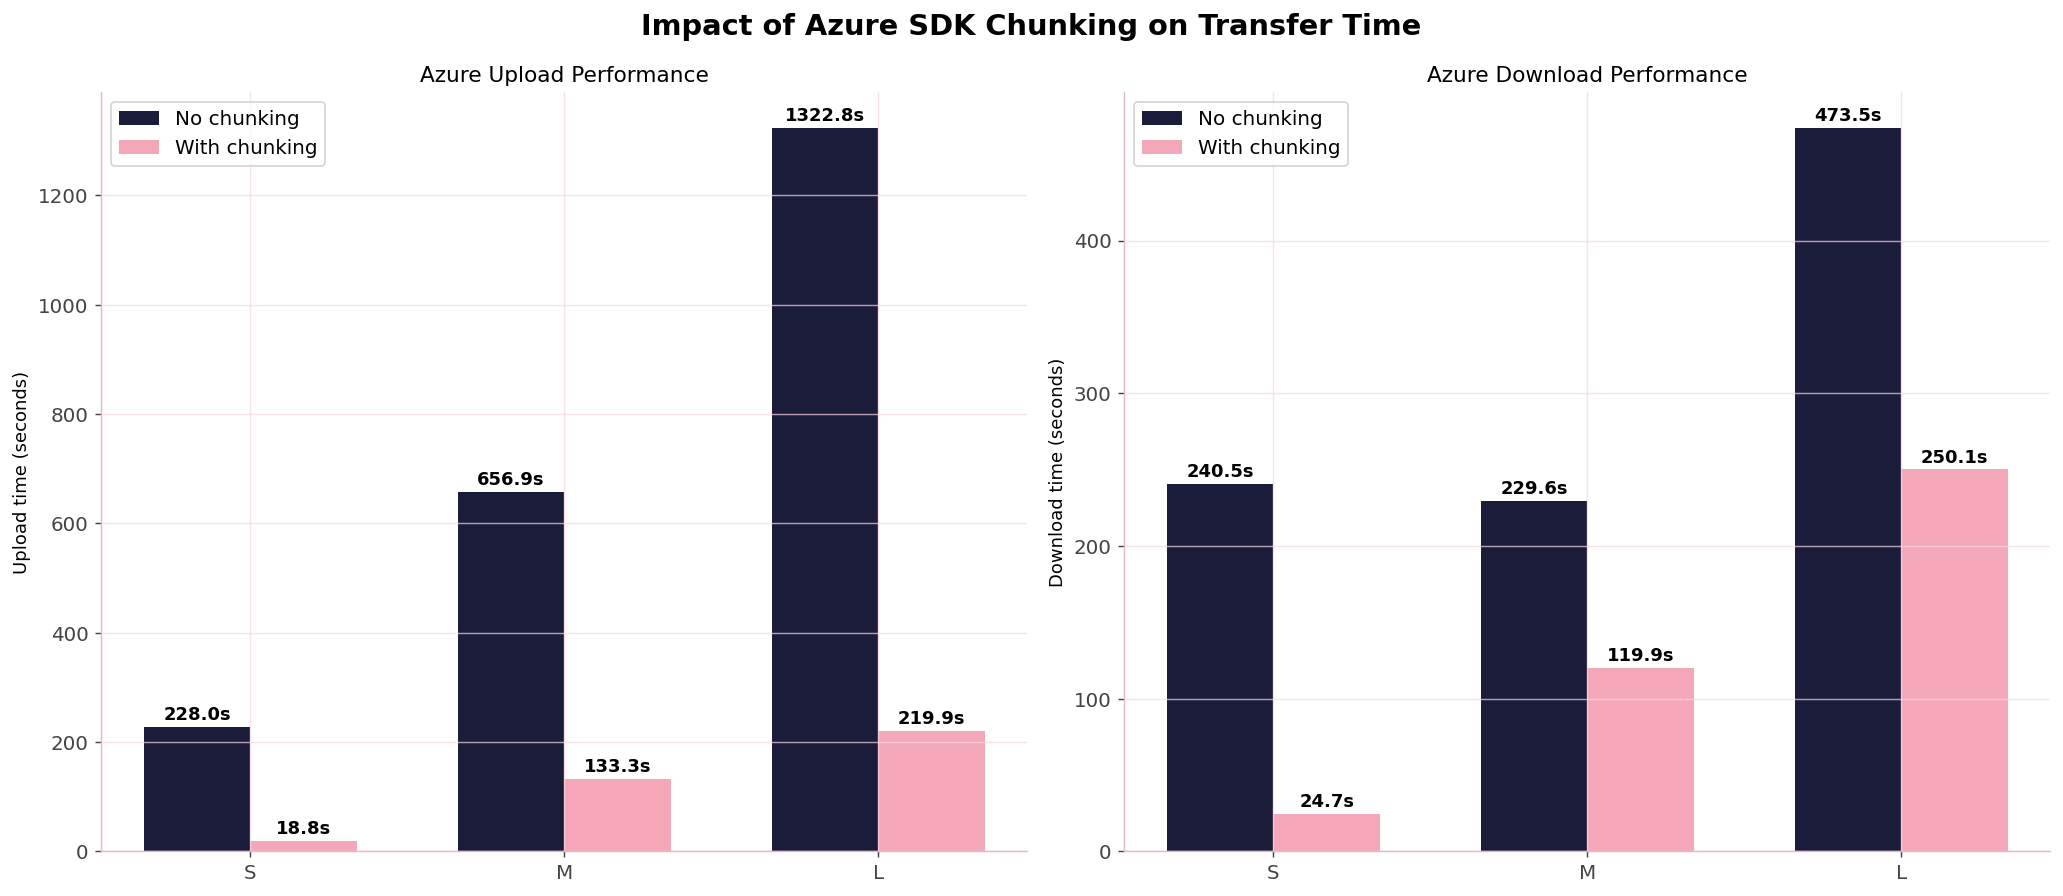


Azure Chunking Speedup
Size  Operation      No chunking       Chunking          Improvement 
----------------------------------------------------------------------
S     Upload         228.0             18.8              12.15       x
S     Download       240.5             24.7              9.73        x
M     Upload         656.9             133.3             4.93        x
M     Download       229.6             119.9             1.91        x
L     Upload         1322.8            219.9             6.01        x
L     Download       473.5             250.1             1.89        x


In [ ]:
# Load CSVs
azure_base = pd.read_csv("results/results-azure.csv")
azure_chunked = pd.read_csv("results/results-azure-chunking.csv")

# Keep only averages
azure_base = azure_base[azure_base["run"] == "avg"]
azure_chunked = azure_chunked[azure_chunked["run"] == "avg"]

# Sizes in order
sizes = ["S", "M", "L"]

# Helper
def get_metric(df, size, operation, metric):
    row = df[
        (df["size"] == size) &
        (df["operation"] == operation)
    ]

    if row.empty:
        return 0

    return float(row.iloc[0][metric])

# Build arrays
azure_nochunk_upload = [
    get_metric(azure_base, s, "upload", "avg_elapsed_s")
    for s in sizes
]

azure_chunk_upload = [
    get_metric(azure_chunked, s, "upload", "avg_elapsed_s")
    for s in sizes
]

azure_nochunk_download = [
    get_metric(azure_base, s, "download", "avg_elapsed_s")
    for s in sizes
]

azure_chunk_download = [
    get_metric(azure_chunked, s, "download", "avg_elapsed_s")
    for s in sizes
]

# Styling
CHUNK_COLORS = {
    "nochunk": PALETTE['midnight'],
    "chunked": PALETTE['glitter']
}

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(sizes))
width = 0.34

# ───────────────── Upload ─────────────────
ax = axes[0]

bars1 = ax.bar(
    x - width/2,
    azure_nochunk_upload,
    width,
    label="No chunking",
    color=CHUNK_COLORS["nochunk"]
)

bars2 = ax.bar(
    x + width/2,
    azure_chunk_upload,
    width,
    label="With chunking",
    color=CHUNK_COLORS["chunked"]
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()

        ax.annotate(
            f"{h:.1f}s",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.set_ylabel("Upload time (seconds)")
ax.set_title("Azure Upload Performance")
ax.legend()

# ───────────────── Download ─────────────────
ax = axes[1]

bars1 = ax.bar(
    x - width/2,
    azure_nochunk_download,
    width,
    label="No chunking",
    color=CHUNK_COLORS["nochunk"]
)

bars2 = ax.bar(
    x + width/2,
    azure_chunk_download,
    width,
    label="With chunking",
    color=CHUNK_COLORS["chunked"]
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()

        ax.annotate(
            f"{h:.1f}s",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.set_ylabel("Download time (seconds)")
ax.set_title("Azure Download Performance")
ax.legend()

# ───────────────── Overall title ─────────────────

plt.suptitle(
    "Impact of Azure SDK Chunking on Transfer Time",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Speedup Table
print("\nAzure Chunking Speedup")
print("=" * 70)

print(
    f"{'Size':<6}"
    f"{'Operation':<15}"
    f"{'No chunking':<18}"
    f"{'Chunking':<18}"
    f"{'Improvement':<12}"
)

print("-" * 70)

for s in sizes:

    # Upload
    old_up = get_metric(azure_base, s, "upload", "avg_elapsed_s")
    new_up = get_metric(azure_chunked, s, "upload", "avg_elapsed_s")

    if old_up > 0:
        improvement = old_up / new_up

        print(
            f"{s:<6}"
            f"{'Upload':<15}"
            f"{old_up:<18.1f}"
            f"{new_up:<18.1f}"
            f"{improvement:<12.2f}x"
        )

    # Download
    old_dl = get_metric(azure_base, s, "download", "avg_elapsed_s")
    new_dl = get_metric(azure_chunked, s, "download", "avg_elapsed_s")

    if old_dl > 0:
        improvement = old_dl / new_dl

        print(
            f"{s:<6}"
            f"{'Download':<15}"
            f"{old_dl:<18.1f}"
            f"{new_dl:<18.1f}"
            f"{improvement:<12.2f}x"
        )

In [63]:
# Full summary table
df[df['test_type'].isin(['upload','download','listing'])].groupby(
    ['backend','size_label','test_type']
).agg(
    runs=('run','count'),
    mean_elapsed_ms=('elapsed_ms','mean'),
    std_elapsed_ms=('elapsed_ms','std'),
    mean_throughput_mb_s=('throughput_mb_s','mean'),
).round(2)

runs  mean_elapsed_ms  std_elapsed_ms  \
backend size_label test_type                                          
azure   L          download      5        451033.50        11408.77   
                   listing       5           124.50           95.23   
                   upload        5       1464667.60       195114.77   
        M          download     15        105225.54       147705.69   
                   listing      10           111.21           70.47   
                   upload       10         54369.23        53753.90   
        S          download      5          5819.57          245.62   
                   listing       5            67.95            5.04   
                   upload        5         93280.21         2504.83   
s3      L          download      5        301329.22        41904.41   
                   listing       5            84.32           59.04   
                   upload        5        317014.78        31111.80   
        M          download      5        193465.12        12497.67   
                   listing       5            83.56           62.55   
                   upload        5        148533.36         3148.31   
        S          download      5         26669.73          726.25   
                   listing       5            65.65            1.58   
                   upload        5         99653.69        21528.34   

                              mean_throughput_mb_s  
backend size_label test_type                        
azure   L          download                  21.17  
                   listing                     NaN  
                   upload                     6.61  
        M          download                   6.39  
                   listing                     NaN  
                   upload                    23.00  
        S          download                   0.00  
                   listing                     NaN  
                   upload                    10.24  
s3      L          download                  32.11  
                   listing                     NaN  
                   upload                    30.31  
        M          download                  24.74  
                   listing                     NaN  
                   upload                    32.13  
        S          download                  35.81  
                   listing                     NaN  
                   upload                     9.86

## 8. Key Findings & Recommendations

### Upload & Download
- S3 upload throughput scales sub-linearly with dataset size due to connection setup costs being amortised: ~10 MB/s (S), ~32 MB/s (M), ~30 MB/s (L). A warm-up effect is observed, where initial runs are slower before stabilising.
- Azure upload performance is highly sensitive to SDK configuration. Without tuning, performance is significantly worse; after setting `max_block_size=8MB` and `max_concurrency=10`, throughput improves to ~18 MB/s (S), ~46 MB/s (M), and ~6.6 MB/s (L), with instability at larger scale.
- S3 download performance is stable across all sizes: 35.8 MB/s (S), 24.7 MB/s (M), 32.1 MB/s (L). Azure download improves after fixing a bug where downloaded bytes were not written to disk, but remains lower overall (~17–21 MB/s for M and L after tuning).
- **Recommendation:** prefer S3 for large sequential transfers due to more stable performance and lower variance.

### Listing
- Listing overhead is negligible across both backends: 65–125 ms for 4–36 objects, with all datasets fitting within a single API page (`list_requests = 1`).
- Azure is slightly slower than S3 for larger object counts (124 ms vs 84 ms for size L), with higher variance.
- **Recommendation:** listing is not a bottleneck at these scales. It may become relevant only at much larger object counts (thousands of files), where fewer and larger files should be preferred.

### Parquet Scan & Predicate Pushdown
- Scan time scales approximately linearly with dataset size: ~30 s (S), ~140–190 s (M), ~265–285 s (L) on S3.
- Aggregation cost is negligible compared to scan time: ~53 ms on average vs >150 s scan time. The workload is fully I/O-bound.
- Predicate pushdown has minimal effect despite large differences in selectivity. For example, preset v4 (0.5% rows matched) and v5 (50.4% rows matched) differ by ~100× in selectivity but only ~5% in runtime (139–188 s range).
- This is explained by uniformly random data generation, which prevents effective row-group skipping based on Parquet statistics.
- **Recommendation:** to improve scan performance, datasets should be physically partitioned by frequently filtered columns (e.g. `region`, `event_type`). Partitioning enables file-level pruning, which is significantly more effective than row-group level filtering.

### Azure vs S3 Scan
- For size S, Azure and S3 are comparable (~30 s each).
- For size M, Azure is significantly slower (600–760 s vs 140–190 s).
- For size L, Azure remains slower (~520 s vs 283 s).
- The performance gap is attributed to higher per-request latency in the `adlfs`/`aiohttp` stack compared to PyArrow’s native `S3FileSystem`, along with retry overhead under instability.
- **Recommendation:** for analytical PyArrow workloads, S3 provides significantly better performance and stability at medium and large scales.

### Manifest-Based Publishing
- Validation dominates publish time in all cases: 2.3 s (S), 6.8 s (M), 13.3 s (L). Manifest writes remain consistently fast (<1 s).
- Publish overhead relative to upload is small and bounded: ~3% (S), ~5% (M), ~4% (L).
- The overhead is stable across scales, with validation cost scaling with dataset size but remaining small compared to transfer time.
- **Recommendation:** manifest-based publishing is a practical approach for safe dataset versioning. It ensures atomic updates (no partial dataset visibility) with minimal overhead.

### Limitations
- All data is synthetically generated with uniform random distributions, which limits realism and likely underestimates the benefit of predicate pushdown in real workloads.
- Transfers are sequential; parallel uploads/downloads would significantly improve throughput.
- No concurrent writer scenarios were tested, so race conditions in the publishing workflow were not evaluated.
- Azure results show higher variance due to SDK instability and occasional connection timeouts, despite retry handling.